In [1]:
import sys
sys.path.insert(0, "/home/quantumer/dmde_class_perturb-CEDE/python/build/lib.linux-x86_64-3.10")
import subprocess

import classy
print("classy imported from: \n",classy.__file__)

from fishchips.experiments import CMB_Primary
from fishchips.cosmo import Observables
import fishchips.util
from classy import Class  # CLASS python wrapper
import numpy as np

classy imported from: 
 /home/quantumer/dmde_class_perturb-CEDE/python/build/lib.linux-x86_64-3.10/classy.cpython-310-x86_64-linux-gnu.so


In [2]:
# create an Observables object to store information for derivatives
# obs = Observables(
#     parameters=['h', 'omega_cdm', 'omega_b', 'A_s', 'n_s', 'tau_reio'],
#     fiducial=[0.6732117, 0.1201075, 0.022032, 2.215e-9, 0.9619, 0.0925],
#     left=[0.6678117, 0.11870750000000001, 0.020632, 2.115e-9, 0.9519, 0.0825],
#     right=[0.6786116999999999, 0.1215075, 0.023432, 2.315e-9, 0.9719, 0.1025])
# obs = Observables(
#     parameters=['h', 'frac_dmde', 'g_scf', 'm_scf'],
#     fiducial=[0.6732117, 0.039, 0.1, 5],
#     left=[0.65, 0.01, 0.01, 0.1],
#     right=[0.72, 0.5, 0.5, 10])
# pars = np.array(['h', 'frac_dmde', 'g_scf', 'm_scf', 'phi_scf_ini', 'omega_cdm', 'omega_b', 'Omega_k', 'N_ur','A_s', 'n_s', 'tau_reio'])
# centers = np.array([0.6732117, 0.8, -0.013, 14.3, 0.695, 0.1201075, 0.022032, 0, 2.0328, 2.215e-9, 0.9619, 0.0925])
# steps = np.array([0.01, 0.1, 0.01, 0.5, 0.1, 0.01, 0.001, 0.01, 0.1, 1e-10, 0.01, 0.01])

pars = np.array(['frac_dmde', 'g_scf', 'm_scf', 'phi_scf_ini',])
centers = np.array([1, 0, 10, 1e-5])
steps = np.array([0.1, 0.01, 0.5, 0.1])


obs = Observables(parameters=pars,
                  fiducial=centers,
                  left=centers,
                  right=centers+steps)

In [3]:
    # left=[0.6678117, 0.0222328, 0.11870750000000001],
    # right=[0.6786116999999999, 0.022532800000000002, 0.1215075]

In [4]:
classy_template = {'output': 'tCl pCl lCl',
                   'l_max_scalars': 2500,
                   'omega_ncdm': 0.0006451439,
                   'h': 0.6732117,
                   'N_ncdm': 1,
                   'm_ncdm': 0.06,
                   'T_ncdm': 0.71611,
                   'A_s':2.215e-9,
                   'n_s':0.9619,
                   'Omega_k': 0,
                   'omega_b': 0.0223828,
                #    'frac_dmde': 0.1,
                #    'g_scf': 0.8,
                #    'm_scf': 0.2,
                  #  'Omega_k': 0.,
                  #  'omega_cdm': 0.1201075,
                  #  'A_s': 2.215e-9,
                  #  'n_s': 0.9619,
                   'tau_reio': 0.0925,
                   # Take fixed value for primordial Helium (instead of automatic BBN adjustment)
                   'YHe':0.245,
                   # other output and precision parameters
                   'lensing': 'yes',
                   'gauge':'synchronous'}
# add in the fiducial values too
classy_template.update(dict(zip(obs.parameters, obs.fiducial)))


In [5]:
# generate the fiducial cosmology
obs.compute_cosmo(key='fiducial', classy_dict=classy_template)

# generate an observables dictionary, looping over parameters
for par, par_left, par_right in zip(obs.parameters, obs.left, obs.right):
    classy_left = classy_template.copy()
    classy_left[par] = par_left
    classy_right = classy_template.copy()
    classy_right[par] = par_right
    # pass the dictionaries full of configurations to get computed
    obs.compute_cosmo(key=par + '_left', classy_dict=classy_left)
    obs.compute_cosmo(key=par + '_right', classy_dict=classy_right)


CosmoSevereError: 

Error in Class: input_init(L:461) :error in input_read_parameters(&(fzw.fc), ppr, pba, pth, ppt, ptr, ppm, psp, pnl, ple, pop, errmsg);
=>input_read_parameters(L:941) :condition (((flag1 == _TRUE_) && (param1>1) )) is true; frac_dmde must be less than 1

['$h$', '$\\frac{dm}{de}$', '$g_{scf}$', '$m_{scf}$', '$\\phi_{scf, ini}$']


(<Figure size 1000x1000 with 25 Axes>,
 array([[<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: ylabel='$\\frac{dm}{de}$'>, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >],
        [<Axes: ylabel='$g_{scf}$'>, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >],
        [<Axes: ylabel='$m_{scf}$'>, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >],
        [<Axes: xlabel='$h$', ylabel='$\\phi_{scf, ini}$'>,
         <Axes: xlabel='$\\frac{dm}{de}$'>, <Axes: xlabel='$g_{scf}$'>,
         <Axes: xlabel='$m_{scf}$'>, <Axes: xlabel='$\\phi_{scf, ini}$'>]],
       dtype=object))

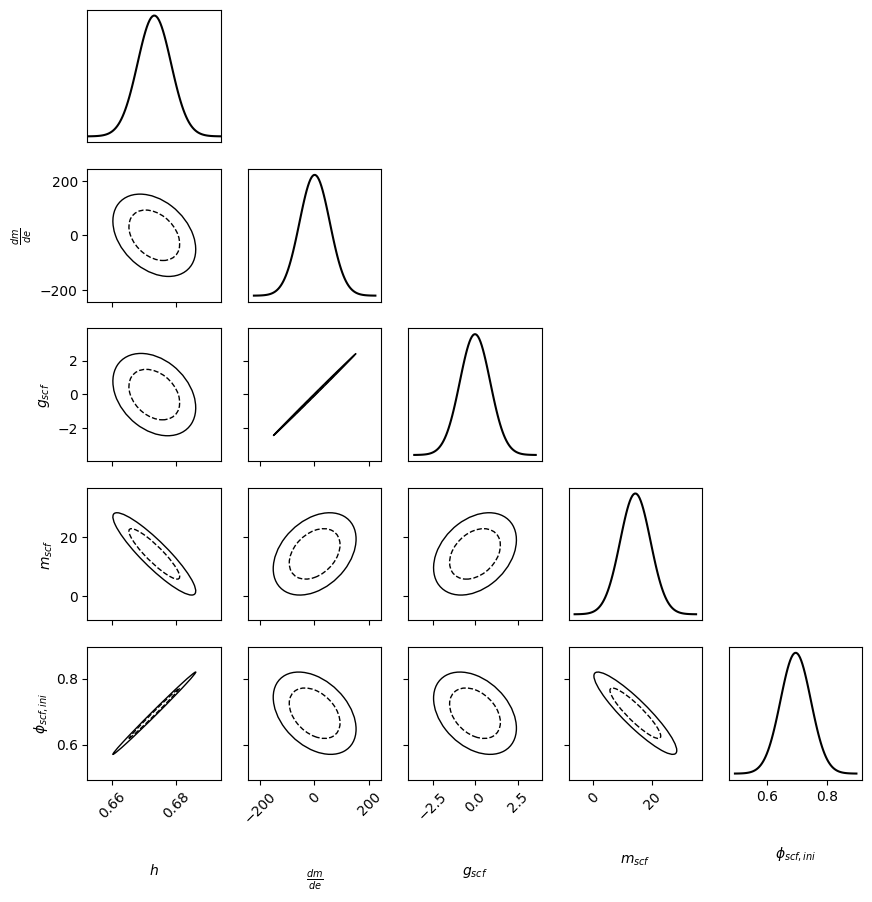

In [ ]:
# compute the Fisher matrix with a Planck-like experiment
example_Planck = fishchips.experiments.CMB_Primary(
    theta_fwhm=[7.], sigma_T=[33.], sigma_P=[56.],
    f_sky=0.65, l_min=2, l_max=2500)
fisher = example_Planck.get_fisher(obs)

# use the plotting utility to get some dope ellipses for 1,2 sigma.
import matplotlib.pyplot as plt
fig, ax = plt.subplots(5, 5, figsize=(10, 10))
cov = np.linalg.inv(fisher)
fishchips.util.plot_triangle(obs, cov, fig, ax,  labels = [r'$h$', r'$\frac{dm}{de}$', r'$g_{scf}$', r'$m_{scf}$', r'$\phi_{scf, ini}$'])

In [8]:
print(np.sqrt(np.diag(cov)))

[9.37932836e-03 1.25585073e-03 1.28465744e-04 1.89536696e-11
 3.42931156e-03 4.41934248e-03]
